<a href="https://colab.research.google.com/github/ChahatUpadhyay/AI_Smartinez_Work/blob/main/Jellyfish_2_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
data_dir = "/content/drive/MyDrive/JellyFIsh/"

img_height, img_width = 224, 224
batch_size = 32
num_classes = 6

In [26]:
Moon_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/Moon_jellyfish"
barrel_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/barrel_jellyfish"
blue_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/blue_jellyfish"
compass_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/compass_jellyfish"
lions_mane_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/lions_mane_jellyfish"
mauve_stinger_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/mauve_stinger_jellyfish"

# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (224, 224))
            images.append(img)
    return images

Moon_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/Moon_jellyfish"
barrel_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/barrel_jellyfish"
blue_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/blue_jellyfish"
compass_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/compass_jellyfish"
lions_mane_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/lions_mane_jellyfish"
mauve_stinger_jellyfish = "/content/drive/MyDrive/JellyFIsh/mauve_stinger_jellyfish"

# Loading images and labels for each emotion
Moon_images = load_images_from_folder(Moon_jellyfish_folder)
barrel_images = load_images_from_folder(barrel_jellyfish_folder)
blue_images = load_images_from_folder(blue_jellyfish_folder)
compass_images = load_images_from_folder(compass_jellyfish_folder)
lions_mane_images = load_images_from_folder(lions_mane_jellyfish_folder)
mauve_stinger_images = load_images_from_folder(mauve_stinger_jellyfish_folder)


# Creating labels for each emotion category
Moon_labels = [0] * len(Moon_images)
barrel_labels = [1] * len(barrel_images)
blue_labels = [2] * len(blue_images)
compass_labels = [3] * len(compass_images)
lions_mane_labels = [4] * len(lions_mane_images)
mauve_stinger_labels = [5] * len(mauve_stinger_images)

all_labels = Moon_labels+barrel_labels+blue_labels+compass_labels+lions_mane_labels+mauve_stinger_labels


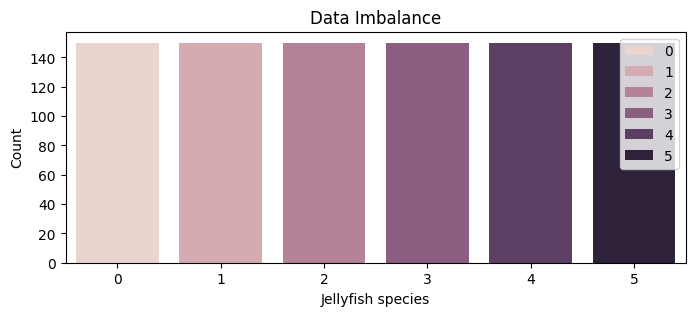

In [27]:
# checking for Data Imbalance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 3))
sns.countplot(x=all_labels, hue=all_labels)
plt.title('Data Imbalance')
plt.xlabel('Jellyfish species')
plt.ylabel('Count')
plt.show()

In [28]:
#Concatenate images and labels
X = np.array(Moon_images + barrel_images + blue_images + compass_images + lions_mane_images + mauve_stinger_images)
y = np.array(Moon_labels + barrel_labels + blue_labels + compass_labels + lions_mane_labels + mauve_stinger_labels)

#Normalize pixel values to range [0, 1]
X = X.astype('float32') / 255.0

Data Augmentation

In [29]:
# here we will double each jellyfish type images
# earlier 150 in each
#after this 300 in each
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Training generator (subset="training")
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=42
)

# Validation generator (subset="validation")
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 720 images belonging to 6 classes.
Found 180 images belonging to 6 classes.


In [ ]:
# Load VGG16 base model with ImageNet weights, excluding the top layers.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freezing all layers of the VGG16 base model initially
for layer in base_model.layers:
    layer.trainable = False

# Adding a custom classification head
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model for initial training
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Fine tuning model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

epochs_finetune = 20

history_finetune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_finetune,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, lr_scheduler]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 277s 12s/step - accuracy: 0.2298 - loss: 2.0116 - val_accuracy: 0.5750 - val_loss: 1.3264 - learning_rate: 1.0000e-04
Epoch 2/20
 1/22 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.2812 - loss: 1.7839

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 384ms/step - accuracy: 0.2812 - loss: 1.7839 - val_accuracy: 0.5437 - val_loss: 1.3710 - learning_rate: 1.0000e-04
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 647ms/step - accuracy: 0.4587 - loss: 1.3588 - val_accuracy: 0.6562 - val_loss: 1.0366 - learning_rate: 1.0000e-04
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.5312 - loss: 1.1714 - val_accuracy: 0.6750 - val_loss: 1.0686 - learning_rate: 1.0000e-04
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 658ms/step - accuracy: 0.5783 - loss: 1.1374 - val_accuracy: 0.7500 - val_loss: 0.8681 - learning_rate: 1.0000e-04
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.7500 - loss: 0.7937 - val_accuracy: 0.6938 - val_loss: 0.8883 - learning_rate: 1.0000e-04
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 641ms/step - accuracy: 0.6523 - loss: 0.9681 - val_accuracy: 0.8062 - val_loss: 0.7416 - learning_rate: 1.0000e-04
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.7812 -

In [ ]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Final Validation Accuracy: {accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.9505 - loss: 0.3159
Final Validation Accuracy: 0.9375


In [30]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, model_name, ax):
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_title(f'{model_name} Learning Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

def plot_accuracy_curves(history, model_name, ax):
    ax.plot(history.history['accuracy'], label='Training Accuracy')
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax.set_title(f'{model_name} Accuracy Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()


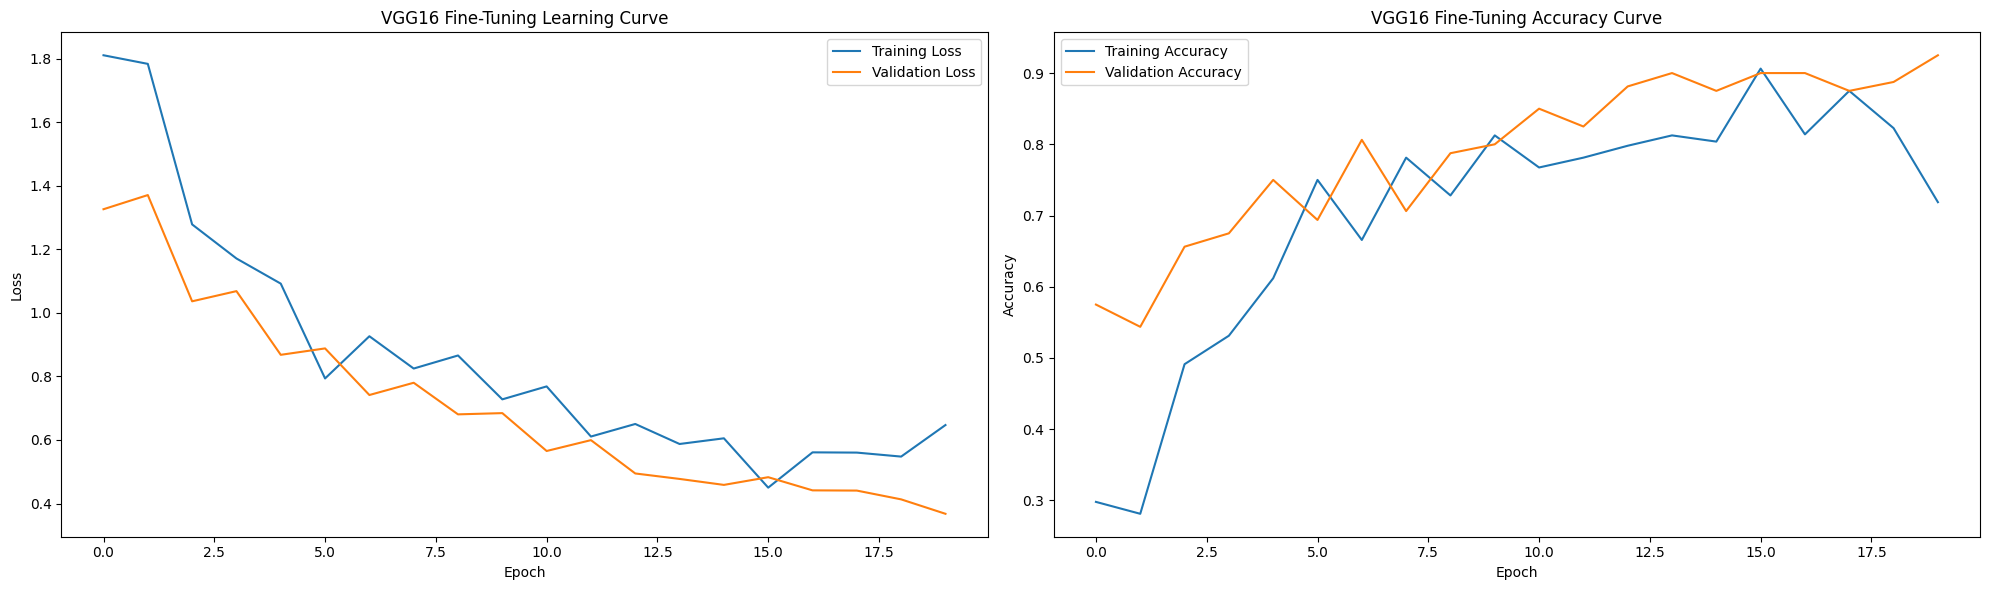

In [31]:

# Assuming you have a fine-tuning training history named "history_finetune"
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

# Plot the learning and accuracy curves for fine-tuning only
plot_learning_curves(history_finetune, 'VGG16 Fine-Tuning', axs[0])
plot_accuracy_curves(history_finetune, 'VGG16 Fine-Tuning', axs[1])

plt.tight_layout()
plt.show()


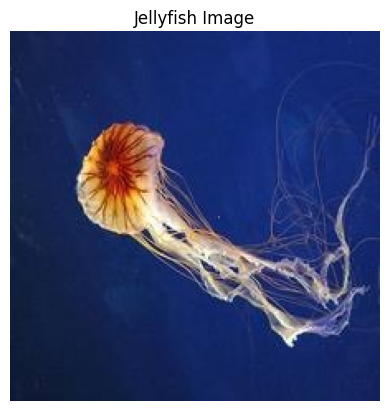

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Class: Compass Jellyfish
Class Probabilities: [[4.6477970e-03 7.8029605e-04 9.1206320e-03 9.5188063e-01 1.8169984e-02
  1.5400617e-02]]


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define a mapping from class index to species names
class_names = {
    0: "Moon Jellyfish",
    1: "Barrel Jellyfish",
    2: "Blue Jellyfish",
    3: "Compass Jellyfish",
    4: "Lions Mane Jellyfish",
    5: "Mauve Stinger Jellyfish"
}

def classify_jellyfish(image_path, model, input_shape):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (input_shape[0], input_shape[1]))

    # Normalize pixel values to [0, 1]
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    #Predicting using our model
    probabilities = model.predict(img)
    class_idx = np.argmax(probabilities, axis=1)[0]

    predicted_class = class_names.get(class_idx, "Unknown")

    return predicted_class, probabilities

# Example usage:
# Replace with your desired image path
image_path = "/content/drive/MyDrive/JellyFIsh/compass_jellyfish/03.jpg"

# Display the image
img = cv2.imread(image_path)
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Jellyfish Image")
    plt.show()

predicted_class, probs = classify_jellyfish(image_path, model, (224, 224, 3))

print("Predicted Class:", predicted_class)
print("Class Probabilities:", probs)


In [ ]:
# Save the model as an HDF5 file
model.save("/content/drive/MyDrive/jellyfish_model_VGG.h5")
print("Model saved as jellyfish_model.h5")

Model saved as jellyfish_model.h5
